In [1]:
import os
import subprocess

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator

import qubovert

from util import *

Importing drawing library

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
RESTARTING = 15
BATCH = 30

Generate QUBO Problem

In [4]:
def gen_qubo(verilog_source):
    try:
        path = os.getcwd()
        subprocess.run(['yosys', verilog_source, 'work/synth.ys', '-b', 'edif', '-o', 'work/circ_sat.edif'], capture_output=True)
        subprocess.run(['edif2qmasm', '-o', 'work/circ_sat.qmasm', 'work/circ_sat.edif'])
        os.chdir('work')
        subprocess.run(['qmasm', '--format', 'numpy', '-o', '../sat.npz', '--solver', 'tabu', '--pin', 'circ_sat.y := true', 'circ_sat.qmasm'])
        os.chdir(path)
        return 0
    except:
        return 1

In [5]:
def gen_ising(qubo_mat):
    ising_dict, ising_mat = convert_to_ising(qubo_mat)
    ising_solution = qubovert.QUSO(ising_dict).solve_bruteforce()
    ising_energy = qubovert.QUSO(ising_dict).value(ising_solution)
    return ising_mat, ising_energy

In [6]:
def initialize_tsv(file):
    column = ["000", "001", "010", "011", "100", "101", "110", "111"]
    with open(file, 'w') as out:
        for i, col in enumerate(column):
            if i < len(column) - 1:
                out.write(col + "\t")
            else:
                out.write(col)
        out.write('\n')

In [7]:
def write_tsv(res, file):
    with open(file, 'a') as out:
        for i, freq in enumerate(res):
            if i < len(res) - 1:
                out.write(str(freq[1]) + '\t')
            else:
                out.write(str(freq[1]))
        out.write('\n')
    return 0

In [8]:
def run_experiments(ansatz, backend, candidate_circuit, cost_hamiltonian, restarting, opt_method, file_tsv):
    for i in range(BATCH):
        energy, n_eval, res, run_time = run_experiment(ansatz, backend, candidate_circuit, cost_hamiltonian, restarting, opt_method)
        print(opt_method, i, run_time, sep='\t')
        write_tsv(res, file_tsv)

In [9]:
def __main__():
    error = gen_qubo('circ_sat.v')
    data, qubo_mat, n_qubits = load_qubo('sat.npz')
    ising_mat, ising_energy = gen_ising(qubo_mat)
    cost_hamiltonian = SparsePauliOp.from_sparse_list(build_paulis(ising_mat), n_qubits)
    ansatz = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=5)
    ansatz.measure_all()
    backend = AerSimulator()
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    candidate_circuit = pm.run(ansatz)

    initialize_tsv('raw_data.tsv')
    run_experiments(ansatz, backend, candidate_circuit, cost_hamiltonian, RESTARTING, 'COBYLA', 'raw_data.tsv')
    return 0

In [10]:
__main__()

COBYLA	0	38.54196572303772
COBYLA	1	39.74836540222168
COBYLA	2	39.99603080749512
COBYLA	3	40.425002336502075
COBYLA	4	38.19599461555481
COBYLA	5	39.894359827041626
COBYLA	6	42.85768008232117
COBYLA	7	39.727396726608276
COBYLA	8	39.67827105522156
COBYLA	9	38.911628007888794
COBYLA	10	35.86327838897705
COBYLA	11	40.999208211898804
COBYLA	12	37.681846618652344
COBYLA	13	36.1568922996521
COBYLA	14	35.6568386554718
COBYLA	15	38.385045766830444
COBYLA	16	36.406763315200806
COBYLA	17	36.90574502944946
COBYLA	18	36.46119546890259
COBYLA	19	36.74011158943176
COBYLA	20	35.90557622909546
COBYLA	21	34.65949988365173
COBYLA	22	38.716421604156494
COBYLA	23	36.92216372489929
COBYLA	24	36.66419315338135
COBYLA	25	36.54243612289429
COBYLA	26	41.417269706726074
COBYLA	27	37.520437717437744
COBYLA	28	35.37520694732666
COBYLA	29	36.94416618347168


0

In [11]:
import pandas as pd
data = pd.read_csv('raw_data.tsv', sep='\t')

x = [1,2,3,4,5,6,7,8]
label = ['000', '001', '010', '011', '100', '101', '110', '111']
y = data.describe().loc['mean']
err = data.describe().loc['std']

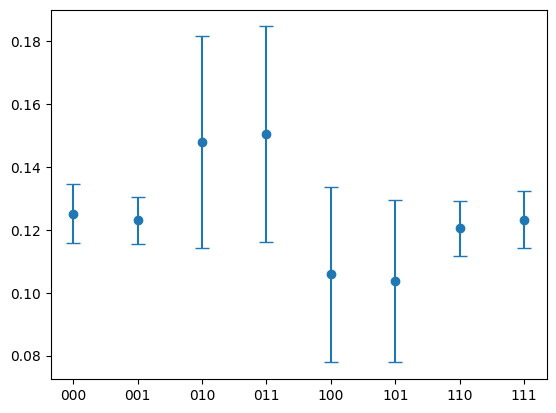

In [12]:
fig, ax = plt.subplots()
ax.errorbar(x,y,err,fmt='o',capsize=5)
ax.set_xticks(x)
ax.set_xticklabels(label)
plt.show()